In [1]:
pip install requests beautifulsoup4 pandas vaderSentiment matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
### get wildfire news links  https://www.cbsnews.com/tag/wildfire/
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

headers = {"User-Agent": "Mozilla/5.0"}

all_articles = []

for page in range(1, 30):  # increase later
    url = f"https://www.cbsnews.com/tag/wildfire/{page}/"
    
    print(f"Scraping page {page}")
    
    res = requests.get(url, headers=headers)
    soup = BeautifulSoup(res.text, "html.parser")
    
    for a in soup.find_all("a", href=True):
        link = a["href"]
        title = a.text.strip()
        
        if "/news/" in link and len(title) > 30:
            full_link = link if link.startswith("http") else "https://www.cbsnews.com" + link
            
            all_articles.append({
                "title": title,
                "url": full_link
            })
    
    time.sleep(1)

df = pd.DataFrame(all_articles).drop_duplicates()

print("Total articles:", len(df))
df.head()

Scraping page 1
Scraping page 2
Scraping page 3
Scraping page 4
Scraping page 5
Scraping page 6
Scraping page 7
Scraping page 8
Scraping page 9
Scraping page 10
Scraping page 11
Scraping page 12
Scraping page 13
Scraping page 14
Scraping page 15
Scraping page 16
Scraping page 17
Scraping page 18
Scraping page 19
Scraping page 20
Scraping page 21
Scraping page 22
Scraping page 23
Scraping page 24
Scraping page 25
Scraping page 26
Scraping page 27
Scraping page 28
Scraping page 29
Total articles: 228


,title,url
0,Millions under wildfire alerts in central U.S....,https://www.cbsnews.com/news/us-fire-weather-a...
1,Dozens of homes destroyed as Georgia wildfires...,https://www.cbsnews.com/atlanta/news/south-geo...
2,El Paso and LA among most polluted U.S. cities...,https://www.cbsnews.com/news/el-paso-los-angel...
3,The West's historic snow drought could bring w...,https://www.cbsnews.com/news/west-historic-sno...
4,"Wildfire smoke pollution linked to 24,100 U.S....",https://www.cbsnews.com/news/wildfire-smoke-po...


In [3]:
import re

def extract_date(soup):
    # Try multiple sources
    
    # 1. meta tags (BEST)
    for tag in soup.find_all("meta"):
        if tag.get("property") in ["article:published_time", "og:published_time"]:
            return tag.get("content")
    
    # 2. time tag
    time_tag = soup.find("time")
    if time_tag:
        return time_tag.get("datetime") or time_tag.text
    
    # 3. fallback regex (last resort)
    text = soup.get_text(" ")
    match = re.search(
        r'(January|February|March|April|May|June|July|August|September|October|November|December)\s\d{1,2},\s\d{4}',
        text
    )
    if match:
        return match.group(0)
    
    return None


def get_article_data(url):
    try:
        res = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(res.text, "html.parser")
        
        # content
        paragraphs = soup.find_all("p")
        content = " ".join([p.text for p in paragraphs])
        
        # clean content
        content = re.sub(r"\s+", " ", content).strip()
        
        # date
        date = extract_date(soup)
        
        return content, date
    
    except:
        return "", None

In [4]:
contents = []
dates = []

for url in df["url"]:
    text, date = get_article_data(url)
    contents.append(text)
    dates.append(date)

df["content"] = contents
df["date_raw"] = dates  # keep raw for debugging

In [5]:
print(df["date_raw"].head(10))

0    2026-04-23T11:50:06-0400
1    2026-04-22T20:11:12-0400
2    2026-03-25T14:15:53-0400
3    2026-03-21T12:37:00-0400
4    2026-02-05T06:28:24-0500
5    2026-01-18T12:22:57-0500
6    2026-04-24T10:02:03-0400
7    2026-04-24T10:07:13-0400
8    2026-04-23T20:08:00-0400
9    2026-04-24T09:38:00-0400
Name: date_raw, dtype: object


In [6]:
df["date"] = pd.to_datetime(df["date_raw"], errors="coerce", utc=True)

# remove timezone
df["date"] = df["date"].dt.tz_localize(None)

In [7]:
df = df.dropna(subset=["date", "content"])
df = df[df["content"].str.len() > 200]

print("Clean dataset:", len(df))

Clean dataset: 228


In [8]:
print(df["date"].dt.year.value_counts())

date
2025    113
2024     68
2026     47
Name: count, dtype: int64


In [9]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]
    
    if score > 0.2:
        return "positive"
    elif score < -0.2:
        return "negative"
    return "neutral"

df["sentiment"] = df["content"].apply(get_sentiment)

In [10]:
trend = (
    df.groupby(df["date"].dt.to_period("M"))["sentiment"]
    .value_counts()
    .unstack()
    .fillna(0)
)

trend.index = trend.index.to_timestamp()

In [12]:
df.to_csv("wildfire_news_final.csv", index=False)

In [13]:
# Convert sentiment → numeric
sent_map = {"positive": 1, "neutral": 0, "negative": -1}
df["sent_score"] = df["sentiment"].map(sent_map)

# Monthly aggregation
monthly = df.groupby(df["date"].dt.to_period("M")).agg({
    "sent_score": "mean",
    "sentiment": "count"
}).rename(columns={"sentiment": "news_volume"})

# Convert index for plotting
monthly.index = monthly.index.to_timestamp()

print(monthly.head())

            sent_score  news_volume
date                               
2024-02-01   -0.500000            4
2024-03-01   -0.882353           17
2024-04-01   -0.400000            5
2024-05-01   -1.000000            4
2024-06-01   -1.000000            7


In [14]:
neg_ratio = (df["sentiment"] == "negative").mean()
volume = len(df)

if neg_ratio > 0.6 and volume > 50:
    risk = "🔴 CRITICAL"
elif neg_ratio > 0.4:
    risk = "🟠 HIGH"
else:
    risk = "🟢 MODERATE"

print("Risk:", risk)

Risk: 🔴 CRITICAL


In [15]:
states = [
    "California", "Texas", "Florida", "Oregon", "Washington",
    "Arizona", "Colorado", "Nevada", "Idaho", "Montana"
]

def detect_state(text):
    for state in states:
        if state.lower() in str(text).lower():
            return state
    return "Other"

df["state"] = df["content"].apply(detect_state)

state_counts = df["state"].value_counts().head(8)

In [16]:
# Safe monthly comparison
if len(monthly) >= 2:
    latest_month = monthly.iloc[-1]
    prev_month = monthly.iloc[-2]
    
    trend_direction = "worsened" if latest_month["sent_score"] < prev_month["sent_score"] else "improved"
else:
    trend_direction = "stable"

# Safe state detection
top_state = df["state"].value_counts().idxmax() if len(df) > 0 else "N/A"

highlight = f"""
🔥 Key Highlights:

• Wildfire sentiment has {trend_direction} this month
• Most affected region: {top_state}
• Risk level: {risk}
• Total news articles analyzed: {len(df)}
"""

/var/folders/dp/f1w59vsn4vqbvdmprd4rcvjw0000gn/T/ipykernel_92717/775960761.py:57: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dp/f1w59vsn4vqbvdmprd4rcvjw0000gn/T/ipykernel_92717/775960761.py:57: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


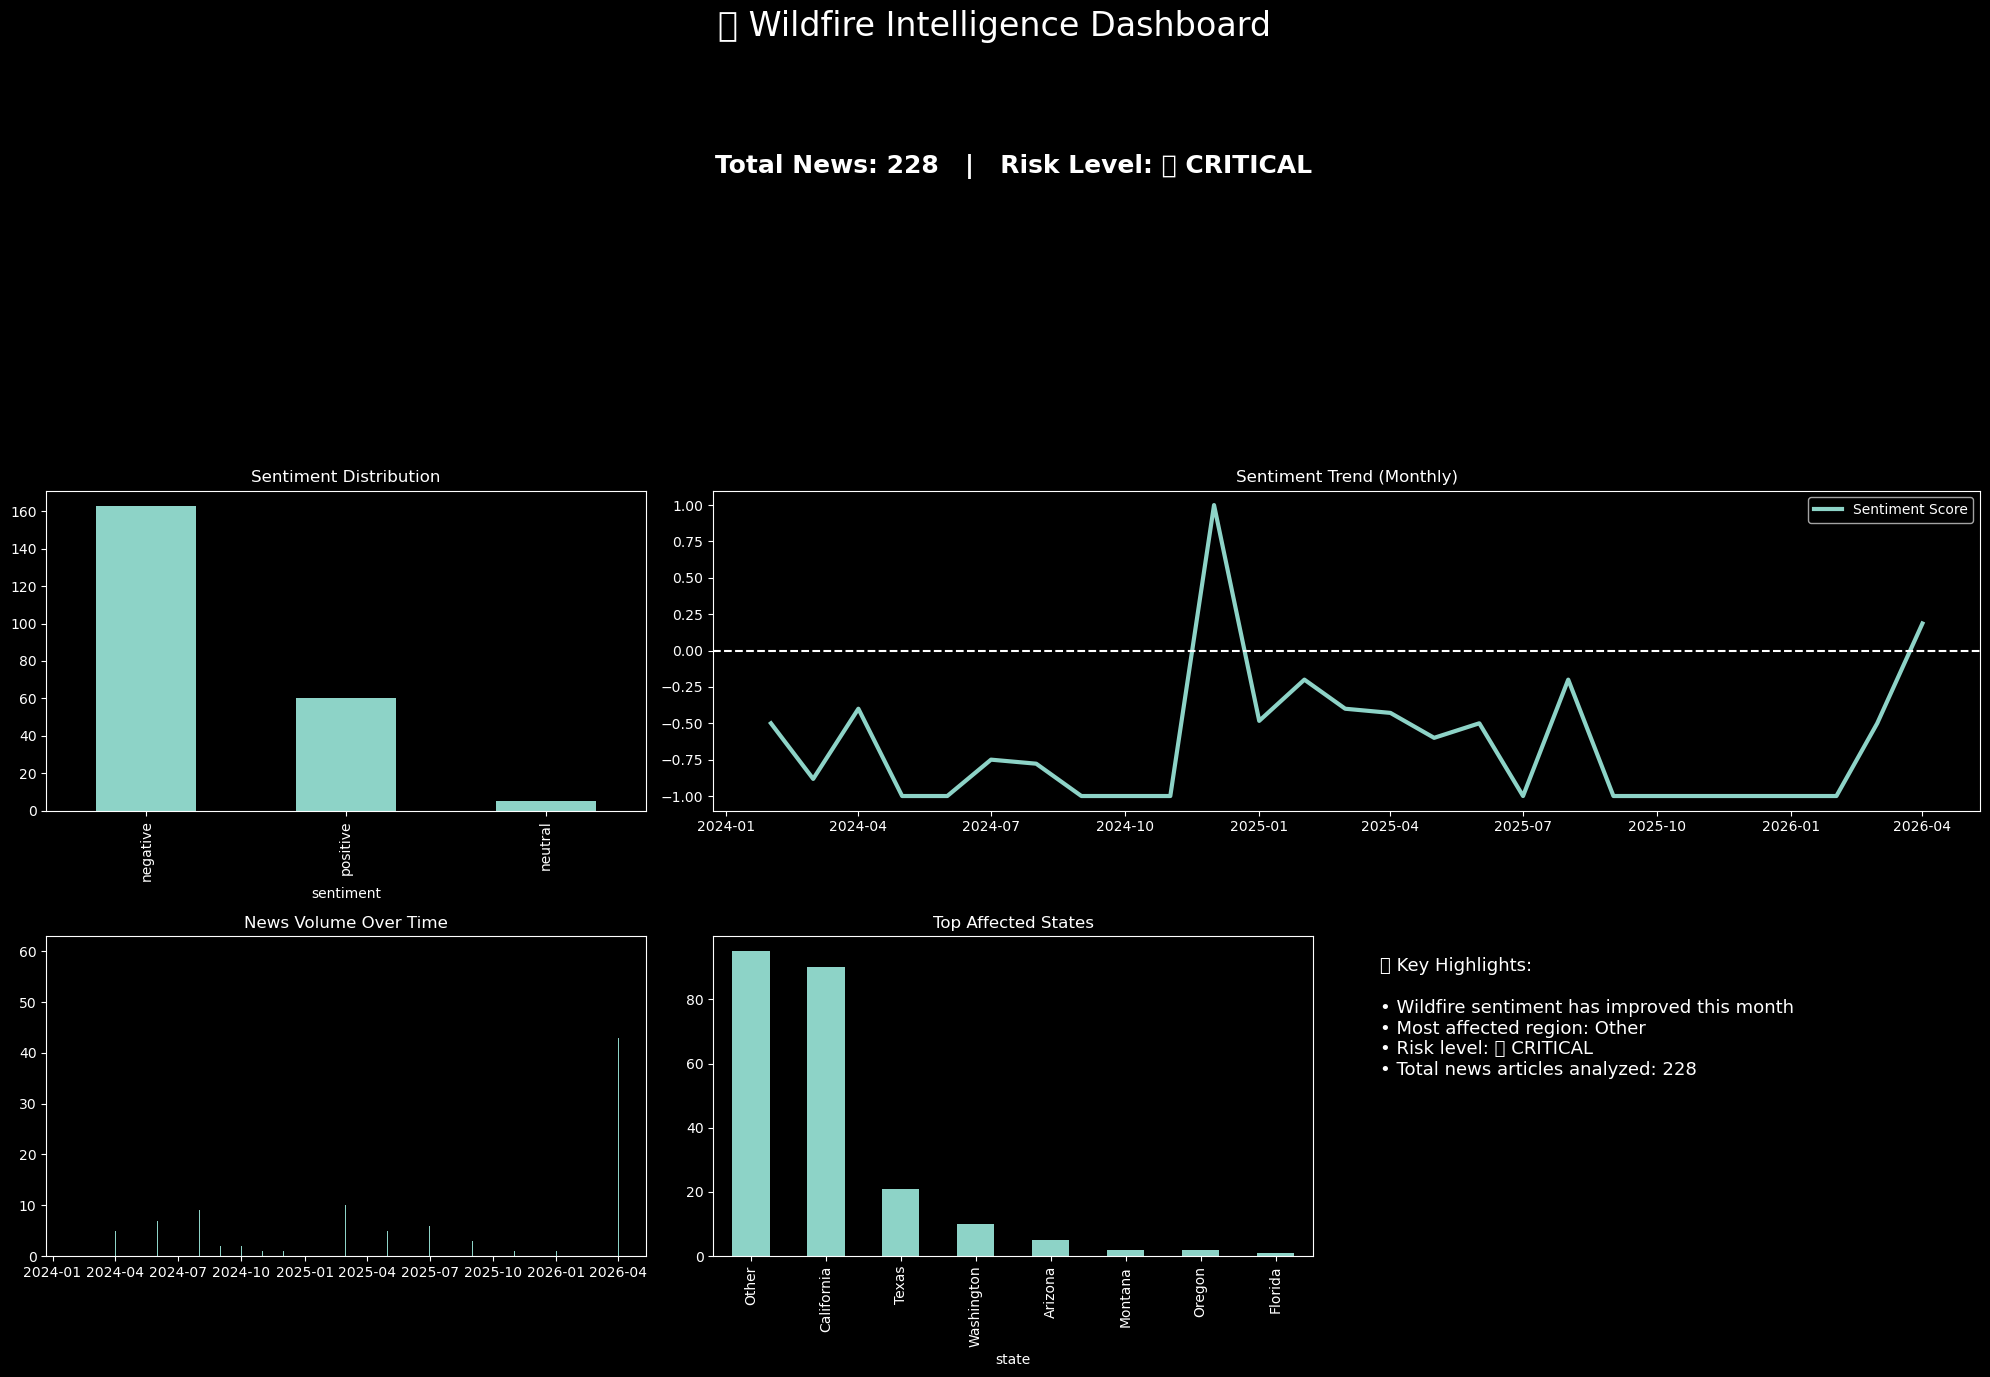

In [17]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")

fig = plt.figure(figsize=(20, 14))
fig.suptitle("🔥 Wildfire Intelligence Dashboard", fontsize=24)

gs = fig.add_gridspec(3, 3)

# -----------------------------
# KPI PANEL
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis("off")

ax_kpi.text(0.5, 0.6,
            f"Total News: {len(df)}   |   Risk Level: {risk}",
            ha="center", fontsize=18, fontweight="bold")

# -----------------------------
# SENTIMENT DISTRIBUTION
ax1 = fig.add_subplot(gs[1, 0])
df["sentiment"].value_counts().plot(kind="bar", ax=ax1)
ax1.set_title("Sentiment Distribution")

# -----------------------------
# SENTIMENT TREND
ax2 = fig.add_subplot(gs[1, 1:])
if len(monthly) > 0:
    for col in monthly.columns:
        if col == "sent_score":
            ax2.plot(monthly.index, monthly[col], linewidth=3, label="Sentiment Score")

ax2.axhline(0, linestyle="--")
ax2.set_title("Sentiment Trend (Monthly)")
ax2.legend()

# -----------------------------
# NEWS VOLUME
ax3 = fig.add_subplot(gs[2, 0])
if len(monthly) > 0:
    ax3.bar(monthly.index, monthly["news_volume"])
ax3.set_title("News Volume Over Time")

# -----------------------------
# STATE DISTRIBUTION
ax4 = fig.add_subplot(gs[2, 1])
state_counts.plot(kind="bar", ax=ax4)
ax4.set_title("Top Affected States")

# -----------------------------
# HIGHLIGHTS PANEL
ax5 = fig.add_subplot(gs[2, 2])
ax5.axis("off")

ax5.text(0, 0.5, highlight, fontsize=13)

plt.tight_layout()
plt.show()

In [18]:
pip install streamlit plotly pandas

Note: you may need to restart the kernel to use updated packages.


In [19]:
df.to_csv("wildfire_news_final.csv", index=False)

In [20]:
!pip install plotly

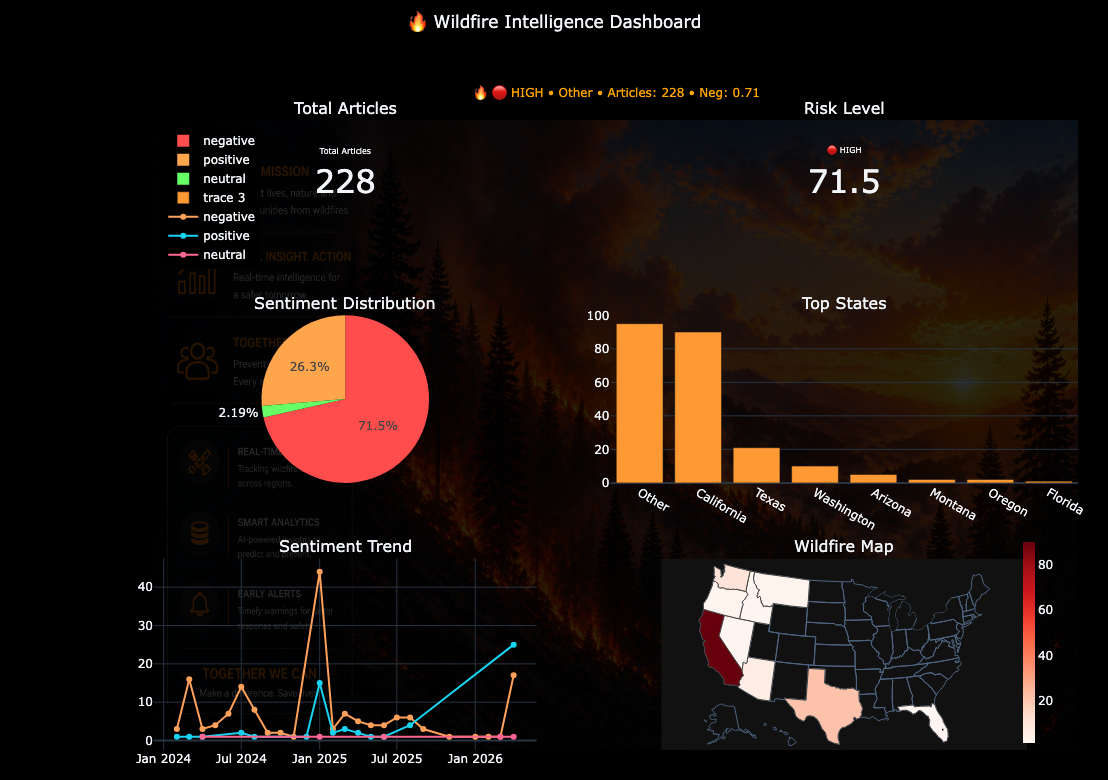

In [22]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import base64

# -----------------------------
# 🔥 LOAD LOCAL IMAGE
def get_base64_image(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()

encoded_image = get_base64_image(
    "/Users/venkatasrideepthisrikotapeetamabaram/Desktop/CrowdDoing Work/NewsPage/Dashboard Background Image.png"
)

# -----------------------------
# DATE FIX
df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)
df["date"] = df["date"].dt.tz_convert(None)
df = df.dropna(subset=["date"])

df["month"] = df["date"].dt.to_period("M").astype(str)

# -----------------------------
# STATE MAP
state_map = {
    "California":"CA","Texas":"TX","Florida":"FL","Oregon":"OR","Washington":"WA",
    "Arizona":"AZ","Colorado":"CO","Nevada":"NV","Idaho":"ID","Montana":"MT"
}
df["state_code"] = df["state"].map(state_map)

# -----------------------------
# DASHBOARD
def build_dashboard(data):

    sent_counts = data["sentiment"].value_counts()
    trend = data.groupby(["month","sentiment"]).size().reset_index(name="count")
    state_counts = data["state"].value_counts().head(8)
    map_data = data.groupby("state_code").size().reset_index(name="count")

    neg_ratio = (data["sentiment"] == "negative").mean()
    risk = "🔴 HIGH" if neg_ratio > 0.6 else "🟠 MODERATE" if neg_ratio > 0.3 else "🟢 LOW"
    top_state = data["state"].value_counts().idxmax()

    # -----------------------------
    # LAYOUT
    fig = make_subplots(
        rows=3, cols=2,
        column_widths=[0.45, 0.55],
        row_heights=[0.25, 0.35, 0.40],
        horizontal_spacing=0.08,
        vertical_spacing=0.12,
        specs=[
            [{"type":"indicator"},{"type":"indicator"}],
            [{"type":"pie"},{"type":"bar"}],
            [{"type":"scatter"},{"type":"choropleth"}]
        ],
        subplot_titles=(
            "Total Articles","Risk Level",
            "Sentiment Distribution","Top States",
            "Sentiment Trend","Wildfire Map"
        )
    )

    # -----------------------------
    # KPI
    fig.add_trace(go.Indicator(
        mode="number",
        value=len(data),
        title={"text":"Total Articles"}
    ), row=1, col=1)

    fig.add_trace(go.Indicator(
        mode="number",
        value=round(neg_ratio*100,2),
        title={"text":risk}
    ), row=1, col=2)

    # -----------------------------
    # PIE
    fig.add_trace(go.Pie(
        labels=sent_counts.index,
        values=sent_counts.values,
        marker=dict(colors=["#ff4d4d","#ffa64d","#66ff66"])
    ), row=2, col=1)

    # -----------------------------
    # BAR
    fig.add_trace(go.Bar(
        x=state_counts.index,
        y=state_counts.values,
        marker=dict(color="#ff9933")
    ), row=2, col=2)

    # -----------------------------
    # TREND
    for s in trend["sentiment"].unique():
        d = trend[trend["sentiment"] == s]
        fig.add_trace(go.Scatter(
            x=d["month"],
            y=d["count"],
            mode="lines+markers",
            name=s
        ), row=3, col=1)

    # -----------------------------
    # MAP (FIXED COLORBAR POSITION)
    fig.add_trace(go.Choropleth(
        locations=map_data["state_code"],
        z=map_data["count"],
        locationmode="USA-states",
        colorscale="Reds",
        colorbar=dict(
            x=0.93,          # ✅ beside map (not outside)
            y=0.17,          # ✅ aligned with map row
            len=0.35,        # ✅ matches map height
            thickness=12,
            outlinewidth=0
        )
    ), row=3, col=2)

    # -----------------------------
    # BACKGROUND
    fig.update_layout(
        images=[dict(
            source=f"data:image/png;base64,{encoded_image}",
            xref="paper",
            yref="paper",
            x=0,
            y=1,
            sizex=1,
            sizey=1,
            sizing="stretch",
            opacity=0.16,
            layer="below"
        )]
    )

    # -----------------------------
    # TITLE
    fig.update_layout(
        title=dict(
            text="🔥 Wildfire Intelligence Dashboard",
            x=0.5,
            y=0.98,
            xanchor="center"
        )
    )

    # -----------------------------
    # INSIGHTS
    fig.add_annotation(
        text=f"🔥 {risk} • {top_state} • Articles: {len(data)} • Neg: {round(neg_ratio,2)}",
        x=0.5,
        y=1.06,
        xref="paper",
        yref="paper",
        showarrow=False,
        font=dict(size=12, color="orange")
    )

    # -----------------------------
    # FINAL STYLE (BALANCED — NO OVERLAP)
    fig.update_layout(
        height=780,
        width=980,
        template="plotly_dark",
        paper_bgcolor="black",
        plot_bgcolor="rgba(0,0,0,0)",
        geo=dict(scope="usa"),
        margin=dict(l=30, r=30, t=120, b=30),  # ✅ reduced right margin
        legend=dict(x=0.01, y=0.99)
    )

    # Smaller KPI font
    fig.update_traces(
        selector=dict(type='indicator'),
        number_font_size=32
    )

    return fig


# -----------------------------
# RUN
fig = build_dashboard(df)
fig.show()